In [34]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [35]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operations: str
    result: int

In [36]:
def adder(state: AgentState):
    """This node add 2 number"""
    state['result'] = state["number1"] + state["number2"]
    return state


def subtract(state: AgentState):
    """This node subtract two number"""
    state["result"] = state["number1"] - state["number2"]
    return state


def decode_next_snode(state: AgentState) -> str:
    """"This node will select the next node of the graph"""
    if state["operations"] == "+":
        return "add_op"
    elif state["operations"] == "-":
        return "subtract_op"
    return None

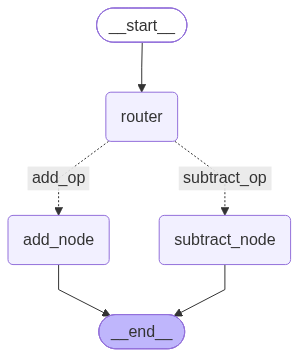

In [37]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtract)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    'router', decode_next_snode,
    {
        "add_op": "add_node",
        "subtract_op": "subtract_node"
    }
)
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

bot = graph.compile()
bot

In [38]:
input_state = {
    "number1": 200,
    "number2": 100,
    "operations": "-"
}

response = bot.invoke(input_state)
response

{'number1': 200, 'number2': 100, 'operations': '-', 'result': 100}